In [1]:
import os
import pandas as pd
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))


BASE = "/kaggle/input/competitions/shopee-product-matching"
df = pd.read_csv(f"{BASE}/train.csv")
columns=["Posting_id","Image","Image_phash","Title","Label_group"]
print(df.shape)
df.head()

        

/kaggle/input/competitions/shopee-product-matching/sample_submission.csv
/kaggle/input/competitions/shopee-product-matching/train.csv
/kaggle/input/competitions/shopee-product-matching/test.csv
/kaggle/input/competitions/shopee-product-matching/train_images/07c251a26b8266c85730ab8d870f1356.jpg
/kaggle/input/competitions/shopee-product-matching/train_images/36dc46d97cdaa7622793e7016976da46.jpg
/kaggle/input/competitions/shopee-product-matching/train_images/b3c7b96aeb0398b152fa5984260a6c57.jpg
/kaggle/input/competitions/shopee-product-matching/train_images/1bd82215202e4e261a1eb8311473c450.jpg
/kaggle/input/competitions/shopee-product-matching/train_images/0b2c815972b87908af3652d2986a55a7.jpg
/kaggle/input/competitions/shopee-product-matching/test_images/0006c8e5462ae52167402bac1c2e916e.jpg
/kaggle/input/competitions/shopee-product-matching/test_images/0008377d3662e83ef44e1881af38b879.jpg
/kaggle/input/competitions/shopee-product-matching/test_images/0007585c4d0f932859339129f709bfdc.jpg
(

,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [2]:
BASE = "/kaggle/input/competitions/shopee-product-matching"
df = pd.read_csv(f"{BASE}/train.csv")
df["title_len"] = df.title.str.len()
df["word_count"] = df.title.str.split().str.len()

t = df.title.str.lower().str.strip()
sizes = df.label_group.value_counts()

# Shopee Product Matching — Part A: Dataset Exploration

**Goal:** understand the dataset and identify what makes product
matching hard, before building any model.

**Problem.** Given around 34k Shopee listings, deciding which listings refer
to the same underlying product. Each listing has a title, an image,
and a perceptual hash of that image. Listings of the same product are
grouped by `label_group`.

**Why this is not ordinary classification.** `label_group` is a
grouping label, not a target class — the competition's test set
contains groups never seen in training. So the task is closer to
retrieval/clustering: learn a representation where same-product
listings land near each other, rather than learn a fixed set of
classes.

**What this notebook covers**
1. Column meanings and basic counts
2. Group-size distribution
3. Duplicate images and near-duplicate titles
4. Title length and language characteristics
5. Hard examples — where text or images alone would fail
6. Challenges and conclusions

In [3]:
print(df.shape)
df.nunique()

(34250, 7)


posting_id     34250
image          32412
image_phash    28735
title          33117
label_group    11014
title_len        184
word_count        51
dtype: int64

In [4]:
dup_imgs = df[df.duplicated("image", keep=False)]
n_groups_per_image = dup_imgs.groupby("image").label_group.nunique()
print((n_groups_per_image > 1).sum())

46


Text(0.5, 1.0, 'Distribution of product-group sizes')

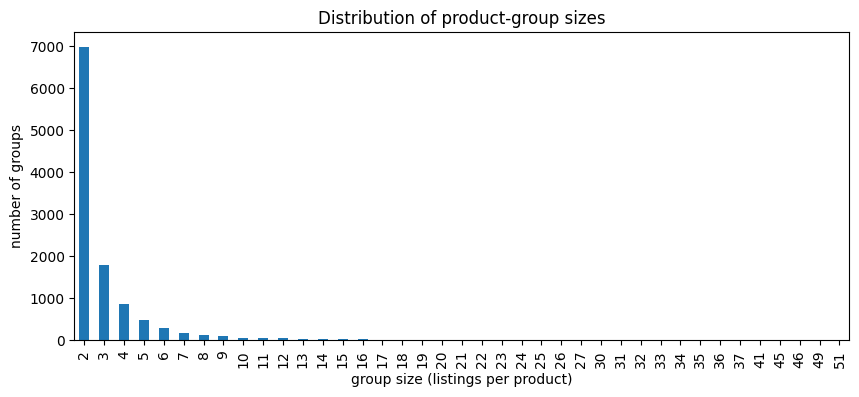

In [5]:
ax = sizes.value_counts().sort_index().plot(kind="bar", figsize=(10, 4))
ax.set_xlabel("group size (listings per product)")
ax.set_ylabel("number of groups")
ax.set_title("Distribution of product-group sizes")

### Group sizes
There are 11,014 groups over 34,250 listings. Every group has at least
2 listings, and 6,979 groups (63%) have exactly 2. The tail is long,
out to a single group of 51.

**Implications**
- Most of the task is matching pairs, so "self plus nearest neighbour"
  is a strong baseline that needs no understanding.
- A group of size 2 and a group of size 51 must share one similarity
  threshold, which is hard.

In [6]:
dup = df[df.duplicated("image", keep=False)]
print((dup.groupby("image").label_group.nunique() > 1).sum())

dup_p = df[df.duplicated("image_phash", keep=False)]
print((dup_p.groupby("image_phash").label_group.nunique() > 1).sum())

46
147


Text(0.5, 1.0, 'Distribution of title lengths')

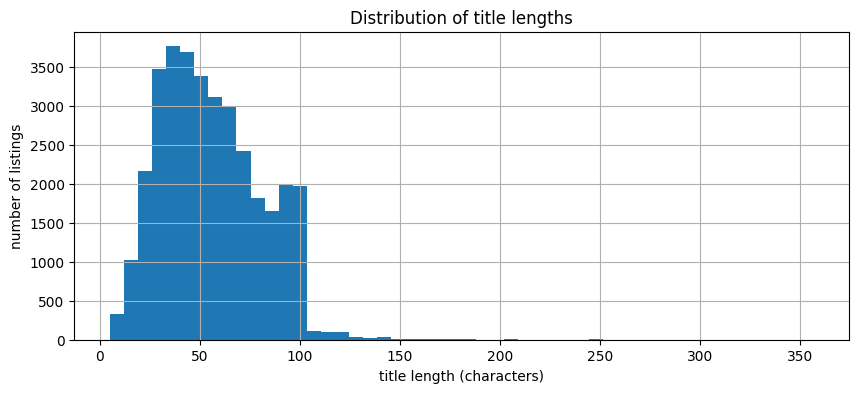

In [7]:
df["title_len"] = df.title.str.len()
df["word_count"] = df.title.str.split().str.len()

ax = df.title_len.hist(bins=50, figsize=(10, 4))
ax.set_xlabel("title length (characters)")
ax.set_ylabel("number of listings")
ax.set_title("Distribution of title lengths")

### Title length
Median title is 53 characters (9 words); min 5, max 357. Most titles
fall between about 20 and 70 characters, with a sharp drop just past
100. [My guess: a length cap near 100, so titles pile up at the limit.
Check whether long titles end mid-word.]

**Implications.** Short titles give TF-IDF few tokens, and very short
ones carry almost no matching signal.

In [8]:
bad = dup_p.groupby("image_phash").label_group.nunique()
bad = bad[bad > 1].index[:4]

for h in bad:
    print(df[df.image_phash == h][["title", "label_group"]].to_string())
    print("---")

                                                                                title  label_group
18519  JF -Kelambu Lipat / kelambu canopy / kelambu anti nyamuk / kelambu anti nyamuk   1876943817
32157     KELAMBU LIPAT KELAMBU TIDUR KELAMBU TEMPAT TIDUR 150X200 180X200 200X200 CM   2829310561
---
                                                                                        title  label_group
1081   JE Kelambu Jaring Tenda Kasur K76 160 x 200 cm Kelambu Tempat Tidur jaring anti nyamuk   1876943817
5531                    KL78 Kelambu Tidur Lipat Korea 180x200 Anti nyamuk & serangga PREMIUM   1424289463
28236                   KL77 Kelambu Tidur Lipat Korea 150x200 Anti nyamuk & serangga PREMIUM   2829310561
---
                                                                                                                         title  label_group
1053                                    Iphone x / xs second to iphone 11Pro / xr second to iphone 11  carbon fiber back sheet 

### Why do different products share a phash?

46 image files and 147 phashes appear in more than one `label_group`
(about 0.5% of the 28,735 distinct phashes). I printed the titles for
several of these collisions to see what the products actually are.

**What I found.** The colliding listings are mostly variants of the
same product line, not unrelated items:
- Kelambu (mosquito nets): 150x200 vs 180x200 cm, plus different
  seller codes (KL77 vs KL78)
- Somethinc serum: 20ml vs 40ml, with almost identical titles
- iPhone carbon-fibre film: same accessory, different phone models

The ground truth treats a size, volume or model difference as a
different product, but sellers appear to reuse one photo across
these variants.

**Images.** [After running show_rows: describe what you actually see.
Are the photos identical? Same product, different backgrounds?]

**Implications for the matching system**
- Image similarity alone cannot separate these cases. The photo is
  the same but the labels differ, so image-only matching has a
  ceiling here.
- The distinguishing information sits in the title's numbers and
  units (`20ml`, `150x200`, `K76`). Text can separate them, but
  only if tokenisation keeps those tokens intact.
- Near-identical titles across different groups (the Somethinc
  pair) are a source of false positives for text matching in Part B.

**Conclusion.** A shared phash is a strong signal of the same photo
(correct roughly 199 times in 200), but not a rule for the same
`label_group`, because sellers reuse photos across variants.

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

def show_rows(rows, n=6):
    rows = rows.head(n)
    fig, axes = plt.subplots(1, len(rows), figsize=(3*len(rows), 3))
    if len(rows) == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, rows.iterrows()):
        ax.imshow(Image.open(f"{BASE}/train_images/{r.image}"))
        ax.set_title(f"{r.title[:35]}\ngrp {r.label_group}", fontsize=7)
        ax.axis("off")
    plt.show()

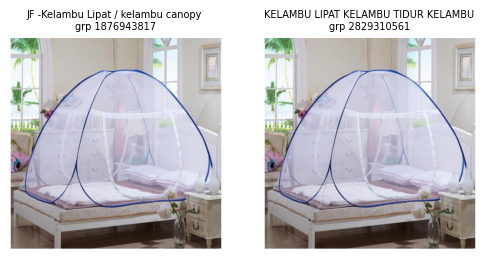

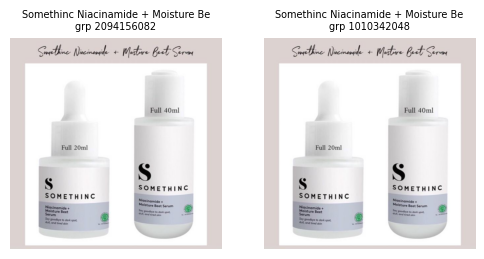

In [10]:
show_rows(df[df.image_phash == bad[0]])   # kelambu
show_rows(df[df.image_phash == bad[3]])   # Somethinc

**Images.** I rendered two collisions. In both, the photos in each pair
are visually identical: the same kelambu photo appears under two
groups, and the same Somethinc banner shows both the 20ml and 40ml size bottles in its pic. So the phash match is
correct at the image level. The label difference comes from the
variant, not from the image.

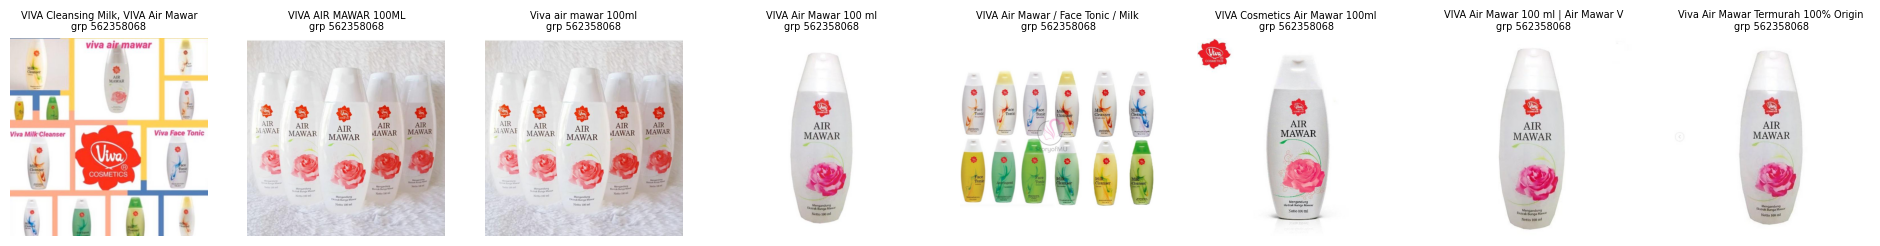

In [11]:
big = sizes.index[0]
show_rows(df[df.label_group == big], n=8)

In [12]:
t = df.title.str.lower().str.strip()
g = df.label_group

def share_with_twin(key):
    # fraction of listings that have another listing in the SAME group with the same key
    return (df.groupby([g, key]).posting_id.transform("count") > 1).mean()

print("same-group twin by exact image :", share_with_twin(df.image))
print("same-group twin by phash       :", share_with_twin(df.image_phash))
print("same-group twin by exact title :", share_with_twin(t))

same-group twin by exact image : 0.08773722627737227
same-group twin by phash       : 0.24861313868613139
same-group twin by exact title : 0.07991240875912409


In [13]:
df[df.label_group == big].image_phash.head(8)


275     a686c86331cd3fac
731     cc91a56a9be26cc9
732     cc91a56a9be26cc9
2141    e699996699666499
2144    b2e9ce16c16712d9
2987    a68b8b05892766fb
3086    b2c9cb6499666699
3592    e699996699266699
Name: image_phash, dtype: object

In [14]:
df[df.label_group == big].title.tolist()


['VIVA Cleansing Milk, VIVA Air Mawar, VIVA Face Toner 100ml',
 'VIVA AIR MAWAR 100ML',
 'Viva air mawar 100ml',
 'VIVA Air Mawar 100 ml',
 'VIVA Air Mawar / Face Tonic / Milk Cleanser 100ml / 200ml [toner penyegar / susu pembersih]',
 'VIVA Cosmetics Air Mawar 100ml',
 'VIVA Air Mawar 100 ml | Air Mawar Viva Pembersih',
 'Viva Air Mawar Termurah 100% Original',
 '[ VIVA ] Air Mawar',
 'Viva Air Mawar',
 'Viva Air Mawar - 100 mL - Penyegar',
 'viva air mawar',
 'Viva Milk Cleanser/ Face Tonic 100ml',
 '\\xe2\\x9d\\xa4 BELIA \\xe2\\x9d\\xa4 Air Mawar Viva 100ml',
 '\\xe2\\x9d\\xa4\\xef\\xb8\\x8fGROSIR\\xe2\\x9d\\xa4\\xef\\xb8\\x8f Viva Milk Cleanser / Face Tonic 100ml',
 'Viva Milk Cleanser Pembersih / Face Tonic Penyegar 100ml',
 'VIVA Milk Cleanser Face Tonic Susu Pembersih Toner Penyegar Air Mawar 100ml',
 'VIVA AIR MAWAR 100ml | AIR MAWAR VIVA PENYEGAR VIVA',
 'Viva Air Mawar',
 'Viva Air Mawar 100ml',
 'VIVA MILK CLEANSER / FACE TONIC / AIR MAWAR 100ml| 200ml',
 'VIVA AIR MAWAR 100

### Inside one large group: label_group 562358068 (51 listings)

I displayed 8 of the 51 listings in the largest group. All are Viva
Air Mawar, so they share one product identity, but they look very
different from each other.

**Images**
- Composition varies: single bottles, a five-bottle lineup, and a
  collage banner showing other Viva products (cleanser, face tonic).
- Backgrounds and decoration vary: plain white, a red logo badge,
  a coloured grid.
- Two of the photos look like the same five-bottle shot resized
  (near-duplicates, which phash can catch).
- The single-bottle shots differ in framing and background, so
  their phashes will differ. [Confirm this by comparing phashes.]

**Titles**
- Casing and formatting differ ("VIVA AIR MAWAR 100ML" vs
  "Viva air mawar 100ml").
- Sellers add filler ("Termurah 100% Origin", "Cosmetics").
- Two titles mention other Viva products (Cleansing Milk, Face
  Tonic). I haven't checked whether these are bundles or labelling
  noise. [Read more of the 51 titles before stating a cause.]

**Why this is hard.** Similarity between members of one true product
is low in both channels. A threshold strict enough to separate
size-2 groups will fragment a group like this one and lose recall.
Image-only matching fails on the collage and multi-bottle photos,
and text-only matching fails when titles differ in wording.

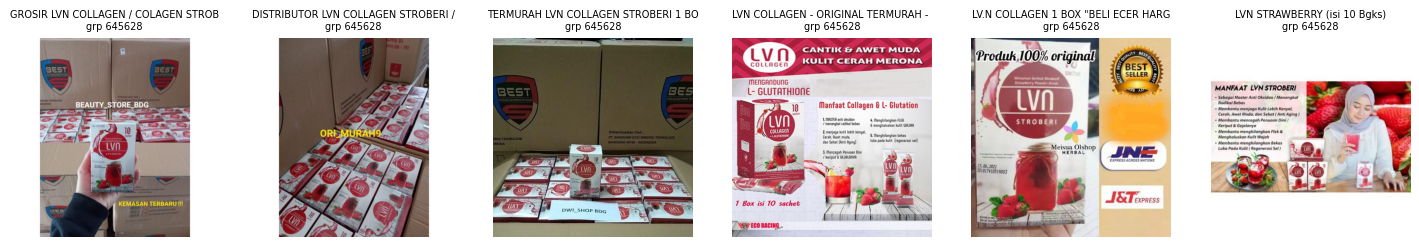

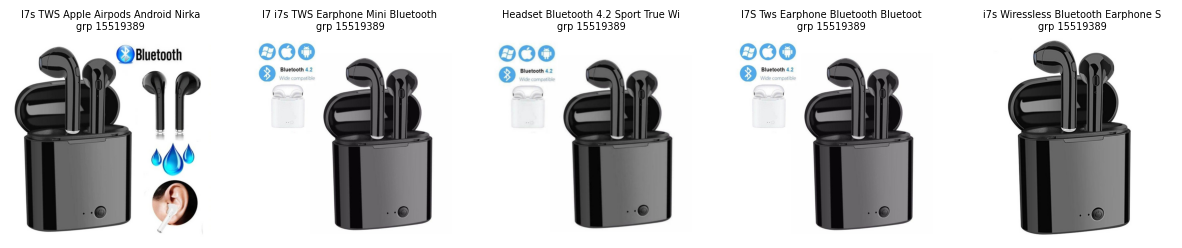

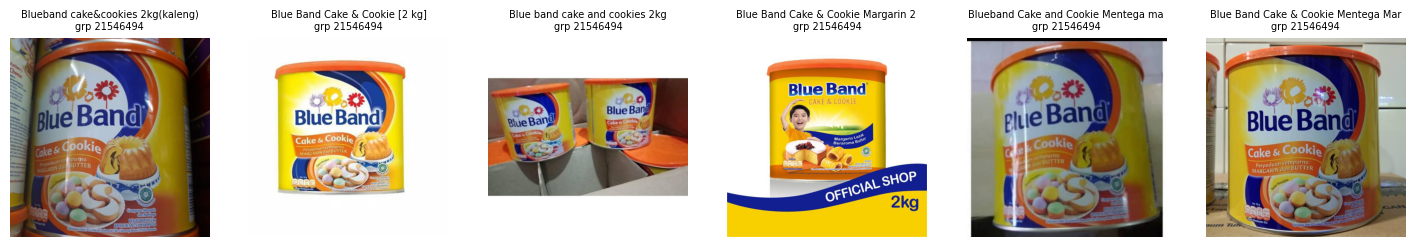

In [15]:
g = df.groupby("label_group").image_phash.nunique()
g = g[g > 3].index[:3]
for x in g:
    show_rows(df[df.label_group == x], n=6)

### Same product, different images
I looked at groups whose listings have many different phashes.
They differ in camera angle , background , position , packaging and the number off items as well and  a person can tell these are one product but phash gives different hashes, so it can't link them.

**Implication.** Matching these needs features that capture what the
object is, not just the image layout. This is the case for learned
embeddings in Part C.

In [16]:
t = df.title.str.lower().str.strip()
g = df.label_group

def share_with_twin(key):
    return (df.groupby([g, key]).posting_id.transform("count") > 1).mean()

print("exact image :", share_with_twin(df.image))
print("phash       :", share_with_twin(df.image_phash))
print("exact title :", share_with_twin(t))

exact image : 0.08773722627737227
phash       : 0.24861313868613139
exact title : 0.07991240875912409


In [17]:
dup_t = df[t.duplicated(keep=False)]
x = dup_t.groupby(t[dup_t.index]).label_group.nunique()
print((x > 1).sum(), "exact titles shared across different groups")

106 exact titles shared across different groups


In [18]:
df.nsmallest(15, "title_len")[["title", "label_group"]]
df.nlargest(5, "title_len").title.tolist()

['Mukena Bali Polos Rayon Janger Jumbo rample Adem Premium \\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80\\xe3\\x80\\x80 #produkbali',
 'Lovely Brown Bear Case OPPO A5 2020/A9 2020 A3S F9 A7 A5S A12 A39 A57 F1S F5 Youth A83 OPPO A1K/Realme C2/F11 Reno A37 Neo 9 Realme C1 5 5S 5i 6I C3 A52 A72 A92Case iPhone 6S Case VIVO Y11 Y12 Y15 Y17 Y91C Y93 Y95 V5S Y71 Y83 Y81 V9 V15 Y11 Y12 Y15 Y17',
 'Soft Case Silikon Motif Kartun Beruang Warna Permen untuk OPPO A53 2020 Reno 4 A5S A5 2020 A3S A92 A31 A12 A9 2020 F9 PRO A37 A37F F1S F11 A1K F7 A52 A71 F5 Youth A7 A31 A33 2020 A91 Reno 2f Reno 3 A72 A12E Realme C15 C12 5i C11 C2 C3 3 3i 5 5S 6 C1 6i',
 'Case Motif Kartun Beruang Lucu dengan Stand untuk 

In [19]:
long5 = df.nlargest(5, "title_len")
long5[["title_len", "label_group"]]

,title_len,label_group
26678,357,905946020
3524,252,3679224078
20702,252,2126962532
24448,250,2126962532
9413,249,676426694


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

rows = [3524, 20702, 24448]
X = TfidfVectorizer(lowercase=True).fit_transform(df.title)
print(cosine_similarity(X[rows]).round(2))

[[1.   0.48 0.49]
 [0.48 1.   0.96]
 [0.49 0.96 1.  ]]


### Noisy and incomplete titles
Titles range from 5 to 357 characters. The longest are noisy in two ways:
- One (Mukena Bali) ends in a long run of escaped bytes
  (`\xe3\x80\x80`), an encoding artifact left in the text.
- Others are phone cases and screen protectors followed by long lists
  of compatible models. Two of the "Beruang" case listings share a
  group and almost the same model list, so the list helps match them.
  A third, from a different group, ends in a similar list. [Cosine
  scores from the TF-IDF check: state what they show.]

Titles also mix Indonesian and English.

**Implications**
- Titles need cleaning (decode or strip escaped bytes, lowercase).
- Long model lists can dominate similarity, which helps within a
  product but can hurt across products fitting the same phones.
- [Shortest titles: what they look like.]

In [21]:
df.nsmallest(15, "title_len")[["title", "label_group"]]

,title,label_group
4009,fullo,1029271551
14695,"Mpek""",2813625930
29427,Gamis,181942707
3598,Nebula,4155543612
3717,3GB UL,4238926989
15327,Plossa,392699942
16329,ORCHID,2326564207
21902,ZR-208,622201978
23824,Masker,3951971428
24107,Tricks,449938131


In [22]:

short = df.nsmallest(15, "title_len")
for _, r in short.head(5).iterrows():
    print(repr(r.title), "->")
    print(df[(df.label_group == r.label_group) & (df.index != _)].title.tolist())
    print()

'fullo' ->
['Fullo Vanila Wafer Roll']

'Mpek"' ->
['Pempek palembang']

'Gamis' ->
['GAMIS MONALISA PREMIUM/GAMIS MOTIF', 'Set akar', 'Gamis Katun Motif Polkadot']

'Nebula' ->
['Nebula - Tere Liye']

'3GB UL' ->
['VOUCHER DATA INDOSAT 3GB UNLIMITED APPS']



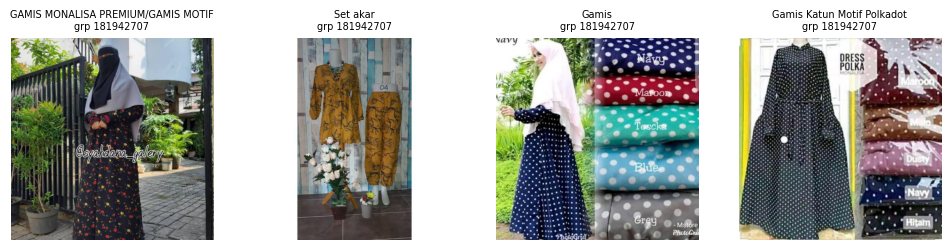

In [23]:
g = df[df.title == "Gamis"].label_group.iloc[0]
show_rows(df[df.label_group == g])

Every group has at least two listings, so I looked at the partners of
five of the shortest titles:
- "fullo" pairs with "Fullo Vanila Wafer Roll" and "Nebula" with
  "Nebula - Tere Liye": a shared word links them.
- "3GB UL" pairs with "VOUCHER DATA INDOSAT 3GB UNLIMITED APPS":
  only "3gb" is shared, because "UL" is an abbreviation of
  "unlimited".
- "Mpek\"" pairs with "Pempek palembang": no shared word, the short
  title looks like a truncated "pempek".
- "Gamis" shares its word with two partners, but a third partner
  ("Set akar") shares nothing. [What the images show.]

So short titles are not always unmatchable from text. Shared words
help, but abbreviations, truncation and unrelated wording leave some
listings with no text link, and the image has to carry them.

**Implication.** Whole-word TF-IDF will miss abbreviations and
truncations. Character n-grams or sentence embeddings are worth
comparing in Part B.

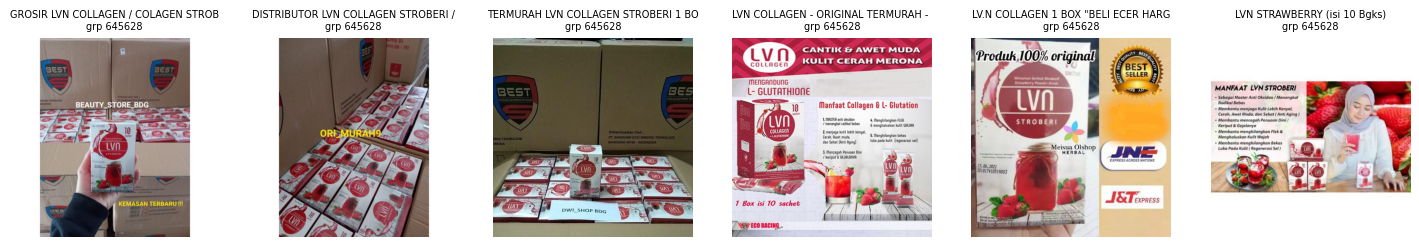

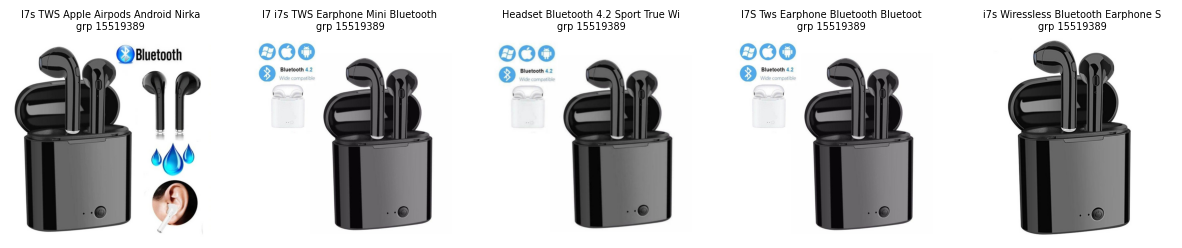

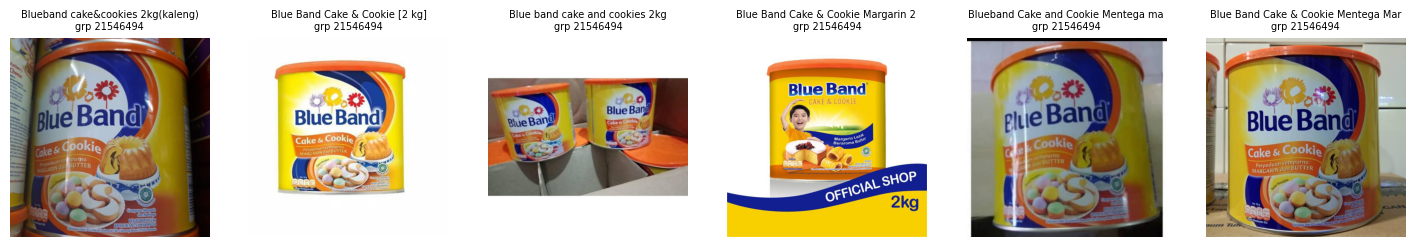

In [24]:
g = df.groupby("label_group").image_phash.nunique()
g = g[g > 3].index[:3]
for x in g:
    show_rows(df[df.label_group == x], n=6)

### Same product, different images
I picked groups whose listings have many different phashes, so the
photos differ, and displayed them.

In group 645628 there are different images of the same product  ,in one a person is holding it whereas in one there is a stack of products which differs their hashes 

**Implication.** Phash links near-duplicate copies of one photo, not
different photos of one product. Matching these needs features that
capture what the object is, which is the reason to use learned image
embeddings in Part C.

In [25]:
dup_t = df[t.duplicated(keep=False)]
x = dup_t.groupby(t[dup_t.index]).label_group.nunique()
print((x > 1).sum())

106


In [26]:
dup_titles = t[t.duplicated(keep=False)].nunique()
print(dup_titles, "distinct titles appear more than once")
print((x > 1).sum(), "of them span more than one group")

1308 distinct titles appear more than once
106 of them span more than one group


In [27]:
bad_titles = x[x > 1].index[:5]
for title in bad_titles:
    print(repr(title))
    print(df[t == title][["label_group", "image_phash"]].to_string())
    print()

'(2kg) shenar rak buku 3d 1x5 susun zaman now'
       label_group       image_phash
16086   1245245655  e4879bd29aa29a99
26695   3314259214  e4a593d39a389a99

'100pcs ikat karet rambut elastis warna polos gaya korea untuk wanita'
       label_group       image_phash
10412    994676122  d5780e316ed58786
22505   2045845868  bb9ac06684987b6b
32857    994676122  f7b9c25864433966

'[ready stock] gluta collagen soap beautetox'
       label_group       image_phash
2819    3064334528  c9978654b59933c6
30842    159351600  e899a3ca34c49d3b

'alat cukur rambut / kumis / jenggot nova ns-216'
       label_group       image_phash
18207   4288078681  8a4a607a3f95adb1
22624   2501975813  e888879733893e1f

'artline stix brush marker etx-f'
       label_group       image_phash
2353    4050048689  db4fa6b0c4d53982
25741   1076586101  e89ec3cb8590b44f



In [28]:
t = df.title.str.lower().str.strip()

dup_t = df[t.duplicated(keep=False)]
title_groups = dup_t.groupby(t[dup_t.index]).label_group.nunique()
ambiguous = title_groups[title_groups > 1].index

print(t[t.duplicated(keep=False)].nunique(), "distinct titles appear more than once")
print(len(ambiguous), "of them span more than one group")
print(t.isin(ambiguous).sum(), "listings carry an ambiguous title")
print(t.isin(title_groups.index).sum(), "listings carry a repeated title")

1308 distinct titles appear more than once
106 of them span more than one group
286 listings carry an ambiguous title
2929 listings carry a repeated title


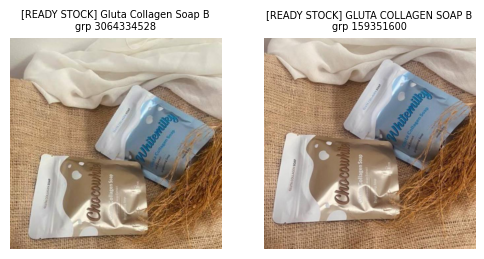

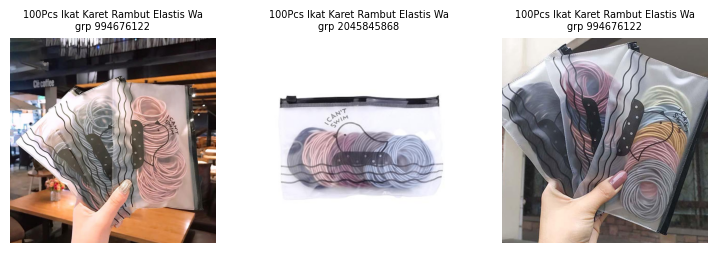

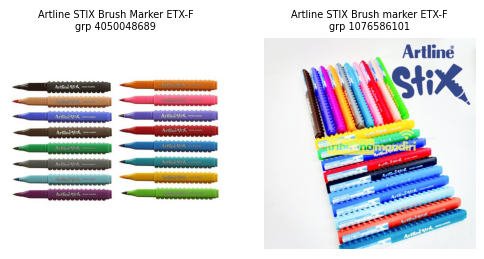

In [29]:
show_rows(df[t == ambiguous[2]])
show_rows(df[t == ambiguous[1]])
show_rows(df[t == ambiguous[4]])

### Same title, different products

After lowercasing and stripping spaces, 1,308 distinct titles appear
more than once, covering 2,929 listings (8.6% of the 34,250). Of
those titles, 106 (8.1%) appear under more than one `label_group`,
covering 286 listings. So when a title repeats, the listing sits
under an ambiguous title about 9.8% of the time, but this affects
only 0.8% of the dataset overall.

I printed the phashes for five of these titles. In all five, the
photos behind the different groups have different phashes. I then
looked at the images for three of them:

- **Gluta collagen soap.** The two photos show the same two soap
  packets on the same background, but they are not the same image:
  their phashes differ by 32 of 64 bits (the distance expected
  between unrelated images) and a pixel comparison gives a mean
  difference of 36.8 on a 0-255 scale, 49.0 if mirrored. They are
  two separate shots of a similar arrangement, not a resized copy.
- **100pcs hair ties.** Two listings in one group show a hand holding
  transparent pouches of hair ties in a café. The listing in the
  other group shows a single flat pouch on a white background. The
  two photos inside the first group also look very different from
  each other.
- **Artline Stix markers.** One photo shows markers lined up in rows
  on white, the other a fan of markers with the Artline Stix logo.

For none of these can I tell from the listing what separates the
groups. It could be a variant, two different sellers, or a labelling
difference, and the title and photos alone do not say.

**Implications**
- An exact title match is right about nine times in ten, but it
  covers few listings: only 8.0% have a same-group listing with an
  identical title.
- Identical text can sit over products that differ, and different
  photos do not rule out a match. Neither the title nor the image is
  enough on its own, which is the argument for combining them.
- Where the cause is unclear, some of the ground truth may not be
  recoverable from the listing at all, which puts a ceiling on any
  model's score.

In [30]:
def hamming(a, b):
    return bin(int(a, 16) ^ int(b, 16)).count("1")

print(hamming("c9978654b59933c6", "e899a3ca34c49d3b"))

32


In [33]:
import numpy as np
a = df.loc[2819]; b = df.loc[30842]
ia = Image.open(f"{BASE}/train_images/{a.image}").convert("L")
ib = Image.open(f"{BASE}/train_images/{b.image}").convert("L")
print(ia.size, ib.size)

ib2 = ib.resize(ia.size)
diff = np.abs(np.asarray(ia, float) - np.asarray(ib2, float)).mean()
flip = np.abs(np.asarray(ia, float) - np.asarray(ib2.transpose(Image.FLIP_LEFT_RIGHT), float)).mean()
print("mean abs pixel diff:", round(diff, 1), "| if mirrored:", round(flip, 1))

(640, 640) (640, 640)
mean abs pixel diff: 36.8 | if mirrored: 49.0


In [34]:
pairs = df[df.duplicated("image_phash", keep=False)].groupby("image_phash").head(2)

## Challenges identified

1. **Variants share photos.** Different sizes or volumes reuse one
   image under different groups (kelambu 150x200 vs 180x200,
   Somethinc 20ml vs 40ml). 147 phashes span more than one group.
2. **Large variation inside one product.** The 51-listing Viva group
   mixes single bottles, a five-bottle lineup and a collage banner,
   with different backgrounds and overlays.
3. **Same product, different photos.** In the LVN, i7s and Blue Band
   groups, a person can see one product but the phashes differ
   (overlays, watermarks, crops, angles).
4. **Identical text over different products.** 106 titles appear
   under more than one group (286 listings).
5. **Identity carried by numbers and units** ("20ml", "150x200",
   "ZR-206"), which tokenisation can destroy.
6. **Very short titles** ("Gamis", "Masker", model codes) carry
   little signal, and some partners share no word with them
   ("Mpek\"" vs "Pempek palembang").
7. **Abbreviations and truncation** ("3GB UL" vs "UNLIMITED").
8. **Formatting noise:** casing, spacing ("Blueband" vs "Blue Band"),
   seller filler ("GROSIR", "Termurah"), stray characters.
9. **Encoding artifacts:** one title ends in a run of escaped bytes.
10. **Long model lists** in phone-case titles dominate the text.
11. **Mixed Indonesian and English** in titles.
12. **Skewed group sizes:** 63% of groups are pairs, one has 51
    listings, and a single threshold has to serve both.
13. **Labels not recoverable from the listing** in some cases (the
    gluta soap and hair-tie groups).

## Answers to the questions to consider

**What makes two listings belong to the same product?**
Two listings are the same product when they share a `label_group`,
which is Shopee's product identity label. Identity is not the same
as looking similar. Listings of one product can look very different
(the 51-listing Viva group mixes single bottles, a five-bottle shot
and a collage banner), while listings that look identical can be
different products (the kelambu and Somethinc photos are the same
image under different groups, because the size or volume differs).

**Can titles alone reliably decide?**
No. An exact title match is right about nine times in ten (106 of
1,308 repeated titles span more than one group), but only 8.0% of
listings have a same-group listing with an identical title, so
exact matching finds few true pairs. Titles also fail the other way:
very short ones ("Gamis", "Masker") carry almost no information,
abbreviations and truncations ("3GB UL", "Mpek\"") share no words
with their partners, and the text that separates variants sits in
numbers and units ("20ml", "150x200").

**Can images alone reliably decide?**
No. A shared phash is strong evidence (147 of 28,735 phashes, about
0.5%, span more than one group), but it reaches only 24.9% of
listings with a same-group partner, and the exact file only 8.8%.
Sellers reuse one photo across variants, so identical images can
hide different products, and one product appears in very different
photos (LVN, i7s, Blue Band), which phash cannot link. An image also
cannot show a size or volume the photo does not display.

**What types of examples are difficult for a model?**
Variants that share a photo and a near-identical title (kelambu
sizes, Somethinc 20ml/40ml); large groups whose members look very
different (the Viva group); very short or abbreviated titles;
photos that show several products at once; identical titles over
different groups (286 listings); and cases where I could not tell
from the listing what separates the groups (the gluta soap pair).
The skewed group sizes also matter: 63% of groups are pairs and one
has 51 listings, so one similarity threshold has to serve both.

**What information could be useful for solving the problem?**
The title text, especially the numbers and units, once casing and
stray characters are cleaned; the image, both as a phash for
near-duplicates and as a learned embedding for different photos of
the same product; the duplicate structure (shared image or phash)
as a strong but imperfect signal; and the group-size distribution as
a prior, since most groups are pairs. Each channel fails where the
other works, so the two should be combined.